# FASE 3: Aprendizaje No Supervisado

**Autor:** Jaime Meléndez Zambrano

## Objetivo
Descubrir patrones y agrupar las respuestas de estudiantes **sin usar las
etiquetas de sentimiento**, usando K-means sobre la representación TF-IDF,
y luego comparar los clusters encontrados contra las categorías reales
(placentero / desagradable / mixto) para ver qué tan bien coinciden.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))
from procesador_nlp import ProcesadorNLP
from clusterizador import ClusterizadorTextos


In [2]:
procesador = ProcesadorNLP()
textos, etiquetas = procesador.cargar_corpus('../data/corpus_etiquetado')


Corpus cargado: 843 textos
Categorías: ['desagradable', 'mixto', 'placentero']


## Preparar datos (TF-IDF) y buscar el k óptimo (método del codo)

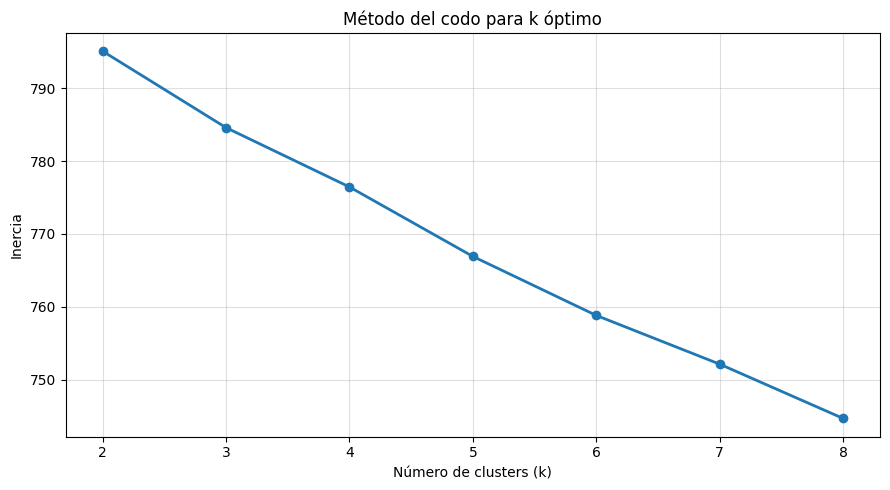

In [3]:
clusterizador = ClusterizadorTextos(textos)
clusterizador.preparar_datos()
inertias = clusterizador.encontrar_k_optimo(max_k=8)
fig = clusterizador.graficar_codo(inertias, max_k=8)
plt.show()


## Apoyo cuantitativo: coeficiente de silueta

El método del codo es visual y algo subjetivo. Como apoyo adicional
(siguiendo la misma idea que usa el proyecto guía en su Fase 5, aunque aquí
se aplica ya en la Fase 3) se calcula el **coeficiente de silueta** para
cada k: mide qué tan bien separados quedan los clusters entre sí (más
cercano a 1 es mejor; cercano a 0 indica clusters que se solapan bastante).

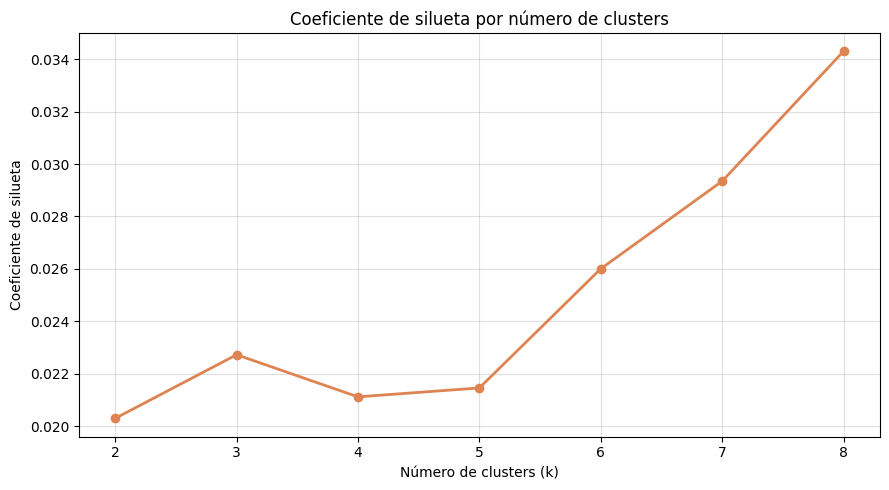

k=2: silhouette=0.0203
k=3: silhouette=0.0227
k=4: silhouette=0.0211
k=5: silhouette=0.0215
k=6: silhouette=0.0260
k=7: silhouette=0.0293
k=8: silhouette=0.0343


In [4]:
scores_silhouette = clusterizador.calcular_silhouette(max_k=8)
fig = clusterizador.graficar_silhouette(scores_silhouette)
plt.show()

for k, s in scores_silhouette.items():
    print(f"k={k}: silhouette={s:.4f}")


**k elegido: 3**

**Justificación:** ni el método del codo ni el coeficiente de silueta
muestran un óptimo extremadamente marcado — es típico en corpus de texto
corto con vocabulario compartido entre categorías, donde los "clusters
naturales" no están tan bien separados como en datos numéricos. Los valores
de silueta son bajos en general (por debajo de 0.05 en todo el rango), lo
que ya es en sí mismo un hallazgo: confirma cuantitativamente que **no hay
una estructura de agrupamiento fuerte** en el espacio TF-IDF de este
corpus, más allá de la que se pueda leer del método del codo. Aun así, se
elige **k=3** porque coincide con el número real de categorías de
sentimiento definidas en la Fase 0, lo que permite una comparación directa
y con sentido pedagógico entre clusters y etiquetas reales.

## Aplicar K-means con k=3

In [5]:
clusters = clusterizador.clusterizar(n_clusters=3)


3 clusters creados
  Cluster 0: 56 textos
  Cluster 1: 354 textos
  Cluster 2: 433 textos


## Visualización de clusters (PCA) — clusters encontrados vs. categorías reales

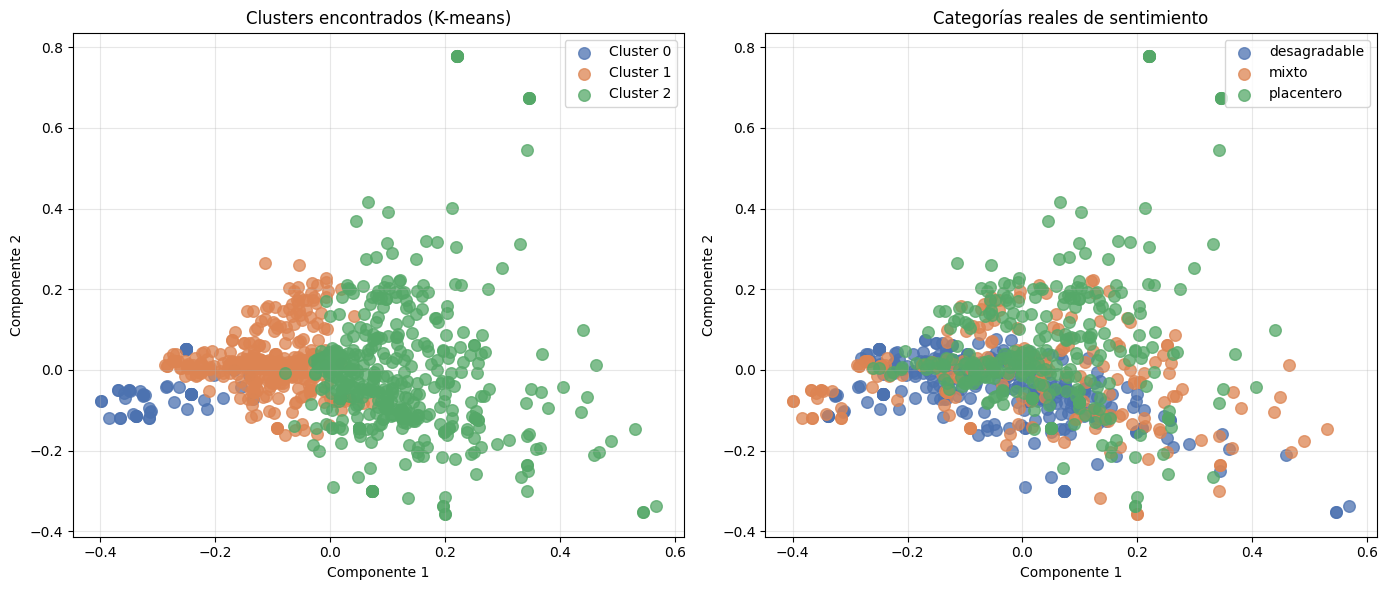

In [6]:
fig = clusterizador.visualizar_clusters(etiquetas_reales=etiquetas)
plt.show()


## Resultados de clustering: palabras características y coincidencia con la categoría real

In [7]:
analisis = clusterizador.analizar_clusters(etiquetas)

filas = []
for cluster_id, info in analisis.items():
    filas.append({
        "Cluster": cluster_id,
        "# Textos": info['num_textos'],
        "Top 5 Palabras": ", ".join(info['top_palabras'][:5]),
        "Categoría Real Mayoritaria": info['categoria_principal'],
        "Coincidencia": f"{info['coincidencia']*100:.1f}%",
    })
tabla_clusters = pd.DataFrame(filas)
tabla_clusters


,Cluster,# Textos,Top 5 Palabras,Categoría Real Mayoritaria,Coincidencia
0,0,56,"deberían, ser, menos, evaluaciones, tareas",desagradable,66.1%
1,1,354,"tareas, volumen, evaluaciones, parece, muchas",desagradable,46.3%
2,2,433,"tiempo, siento, bien, casa, colegio",placentero,46.9%


## Textos "mal ubicados" (no coinciden con la categoría mayoritaria de su cluster)

In [8]:
mal_ubicados = []
for cluster_id, info in analisis.items():
    for idx in info['textos_indices']:
        if etiquetas[idx] != info['categoria_principal']:
            mal_ubicados.append({
                "cluster": cluster_id,
                "categoria_real": etiquetas[idx],
                "categoria_principal_del_cluster": info['categoria_principal'],
                "texto": textos[idx][:90] + ("..." if len(textos[idx]) > 90 else ""),
            })

mal_ubicados_df = pd.DataFrame(mal_ubicados)
print(f"Total de textos 'mal ubicados': {len(mal_ubicados_df)} de {len(textos)}")
mal_ubicados_df.head(10)


Total de textos 'mal ubicados': 439 de 843


,cluster,categoria_real,categoria_principal_del_cluster,texto
0,0,mixto,desagradable,"Me parece que las tareas son necesarias, pero ..."
1,0,mixto,desagradable,"Pienso que, en algunas ocasiones, la cantidad ..."
2,0,mixto,desagradable,"Creo que las tareas son necesarias, pero deber..."
3,0,mixto,desagradable,"Creo que las evaluaciones son necesarias, pero..."
4,0,mixto,desagradable,"Opino que las evaluaciones son importantes, pe..."
5,0,mixto,desagradable,"Creo que los proyectos son necesarios, pero de..."
6,0,mixto,desagradable,"Opino que las evaluaciones son importantes, pe..."
7,0,mixto,desagradable,"Me parece que las tareas son necesarias, pero ..."
8,0,mixto,desagradable,"Creo que las evaluaciones son importantes, per..."
9,0,mixto,desagradable,"Opino que las evaluaciones son necesarias, per..."


## Reflexión de la Fase 3

**¿Coinciden los clusters con las categorías reales?**
Solo parcialmente (ver columna "Coincidencia" en la tabla). El coeficiente
de silueta —consistentemente bajo para cualquier valor de k probado—
confirma con un número, no solo con la inspección visual del PCA, que el
espacio TF-IDF de este corpus no tiene una estructura de agrupamiento
fuerte: K-means agrupa por **similitud de vocabulario**, y el vocabulario
en este corpus está más relacionado con el **tema** de la respuesta (tiempo
libre vs. volumen de tareas) que con su **polaridad emocional**. Dos
respuestas pueden hablar del mismo tema con sentimientos opuestos y aun así
compartir muchas palabras (ambas mencionan "tiempo", "colegio", "tareas").

**¿Qué cluster es más homogéneo? ¿Cuál es más mixto?**
Ver la tabla de arriba: el cluster con mayor coincidencia porcentual es el
más "puro" temáticamente, mientras que el de menor coincidencia mezcla más
categorías reales — típicamente el que agrupa respuestas sobre "tiempo
libre" en general, un tema donde aparecen las tres categorías con
frecuencia similar.

**¿Qué textos están "mal ubicados" según las etiquetas reales?**
Ver la tabla anterior. En su mayoría son respuestas "mixtas" agrupadas en
clusters de mayoría "desagradable" o "placentero" (comparten casi todo el
vocabulario de una polaridad, y solo se diferencian por una cláusula breve
de la polaridad opuesta que TF-IDF no pesa lo suficiente) — un patrón que
ya se observaba en la versión anterior del proyecto y que se mantiene, ahora
sobre una base de datos mucho más grande y diversa.

**¿Qué ventaja tiene el clustering sobre la clasificación supervisada?**
El clustering no necesita etiquetas para funcionar, por lo que sirve para
explorar el corpus (revelar sub-temas como "tiempo libre" vs. "carga
académica") incluso antes de tener un etiquetado de sentimiento. Es útil
como paso exploratorio o para detectar posibles errores de etiquetado (un
texto etiquetado como "placentero" que cae en un cluster casi 100%
"desagradable" es candidato a revisión manual) — de hecho, esta misma
lógica es la que se usó para decidir qué textos ambiguos excluir del
corpus de entrenamiento en la Fase 0.